# Notebook Tema 4 VA, Master IA UMU, curso 2025/26 (_Hand Engineered Features_)



# Imports necesarios

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import math
import skimage
import skimage.transform as transform
import skimage.feature as feature
import skimage.draw as draw
import skimage.color as color
from skimage.feature import blob_dog, blob_log, blob_doh
from skimage.feature import hog
from skimage import data, exposure
from matplotlib import colors as mcolors

# Imágenes de prueba

In [2]:
img_checkerboard = skimage.data.checkerboard()
imgs_motorcycle = skimage.data.stereo_motorcycle()[:2]
img_camera = skimage.data.camera()
img_hubble_gray = color.rgb2gray(data.hubble_deep_field()[0:500, 0:500])

In [3]:
!wget https://pns2019.github.io/images/Lenna.png
# LINK ALTERNATIVO:
# wget https://univmurcia-my.sharepoint.com/:i:/g/personal/pedroe_um_es/Ea29E3_ajmpIv5CY-oHJG_EBZI5bEcRTgAy4Fdmiz6fw0g?download=1 -O Lenna.png
!wget http://ditec.um.es/~pedroe/HOML-scene.jpg
# LINK ALTERNATIVO:
# wget https://univmurcia-my.sharepoint.com/:i:/g/personal/pedroe_um_es/EdYkXi6_9IdKqLmfp9wj9_kBdVnVg3N4rL-hcLZDyWo_pw?e=7sId0u?download=1 -O HOML-scene.jpg
!wget http://ditec.um.es/~pedroe/HOML-model.jpg
# LINK ALTERNATIVO:
# wget https://univmurcia-my.sharepoint.com/:i:/g/personal/pedroe_um_es/Ef5wtN379pVLlAg-NjeDR6kB6Ks5OzgNfZ2fI2W_G6hhYQ?e=Sinyu6?download=1 -O HOML-model.jpg

--2025-10-21 08:17:20--  https://pns2019.github.io/images/Lenna.png
Resolving pns2019.github.io (pns2019.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to pns2019.github.io (pns2019.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 473831 (463K) [image/png]
Saving to: ‘Lenna.png’

Lenna.png           100%[===================>] 462.73K  --.-KB/s    in 0.03s   

2025-10-21 08:17:20 (14.9 MB/s) - ‘Lenna.png’ saved [473831/473831]

--2025-10-21 08:17:20--  http://ditec.um.es/~pedroe/HOML-scene.jpg
Resolving ditec.um.es (ditec.um.es)... 155.54.204.49
Connecting to ditec.um.es (ditec.um.es)|155.54.204.49|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 59696 (58K) [image/jpeg]
Saving to: ‘HOML-scene.jpg’

HOML-scene.jpg      100%[===================>]  58.30K   197KB/s    in 0.3s    

2025-10-21 08:17:21 (197 KB/s) - ‘HOML-scene.jpg’ saved [59696/59696]

--2025-10-21 08:17:21--  http:/

# Detector de bordes de Canny

Ilustración de detector de bordes clásico más famoso (operador de Canny):

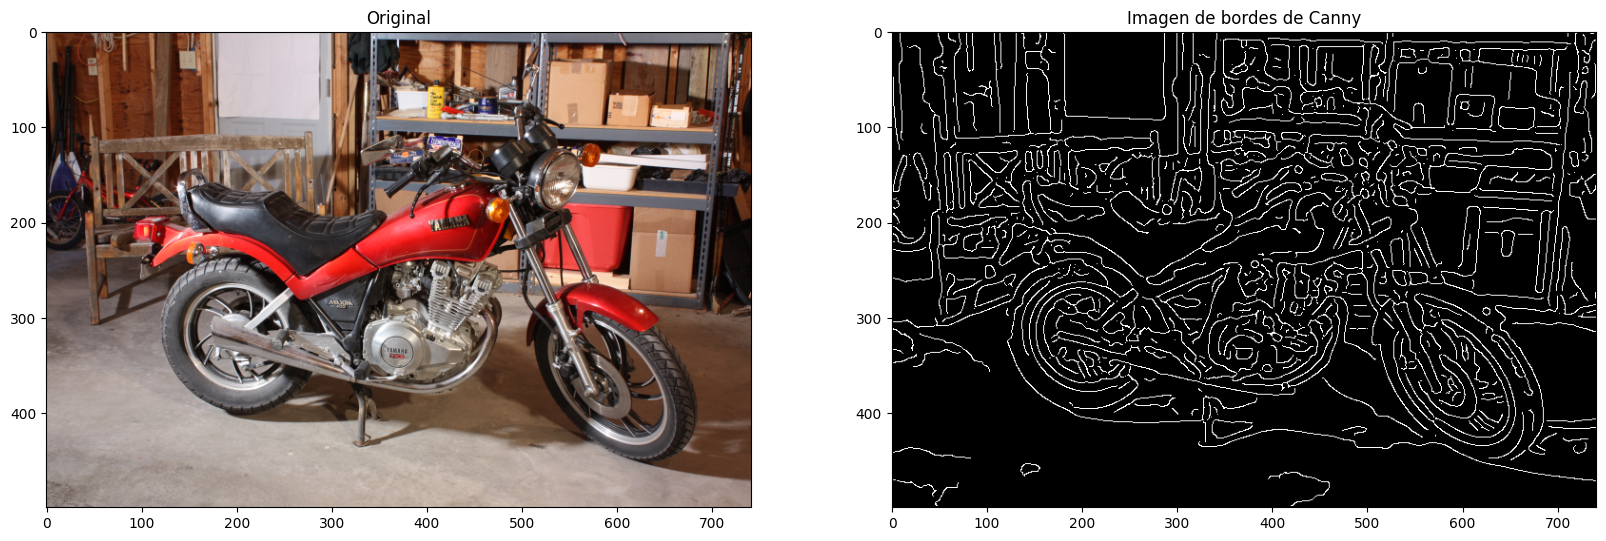

In [5]:
fig, axs = plt.subplots(1,2, figsize=(20,10))
axs[0].imshow(imgs_motorcycle[0])
axs[0].set_title("Original")
axs[1].imshow(feature.canny(color.rgb2gray(imgs_motorcycle[0]), sigma=3, low_threshold=0.1, high_threshold=0.5, use_quantiles=True), cmap="gray")
axs[1].set_title("Imagen de bordes de Canny");

# Extracción de segmentos

Detector de segmentos aplicado a una imagen binaria obtenida mediante el operador de Canny:

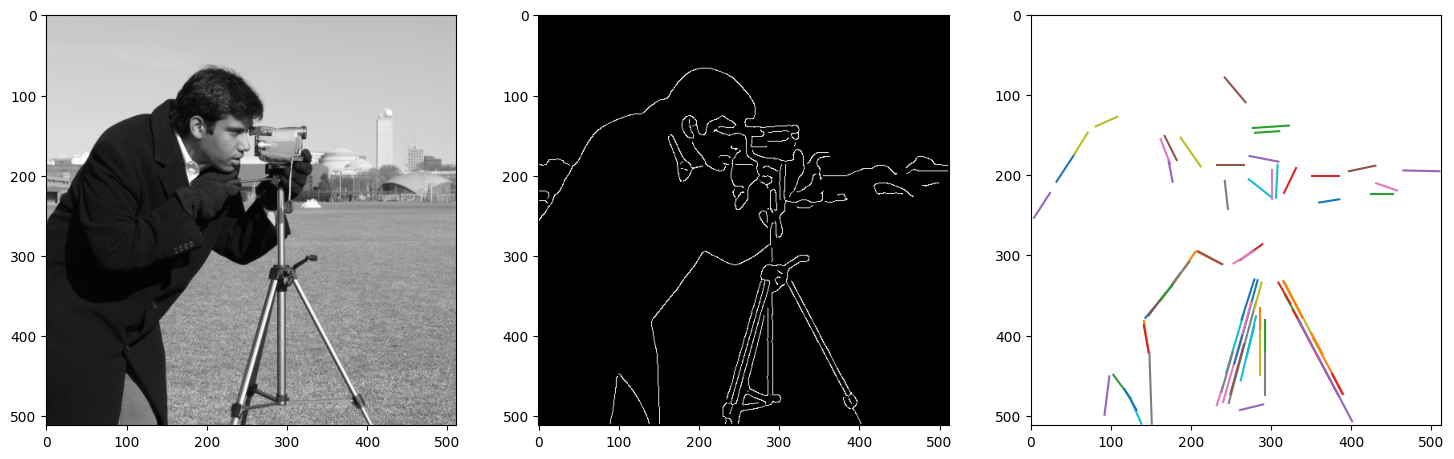

In [6]:
img_edges = feature.canny(img_camera, sigma=3)
lines = transform.probabilistic_hough_line(img_edges, threshold=1, line_length=25, line_gap=5)
fig, ax = plt.subplots(1,3,figsize=(18,6))
ax[0].imshow(img_camera,cmap="gray")
ax[1].imshow(img_edges,cmap="gray")
ax[2].set_xlim((0, img_camera.shape[1]))
ax[2].set_ylim((img_camera.shape[0], 0))
ax[2].set_aspect('equal')
for line in lines:
    p0, p1 = line
    ax[2].plot((p0[0], p1[0]), (p0[1], p1[1]));

# Detector de puntos de Harris

He aquí un ejemplo de detección de puntos cuya estructura fotométrica alrededor tiene textura suficiente para poder hacer viable un _matching_ sin la ambigüedad inherente a las zonas planas de imagen o a los bordes rectos (problema de apertura). Se trata del operador de Harris:

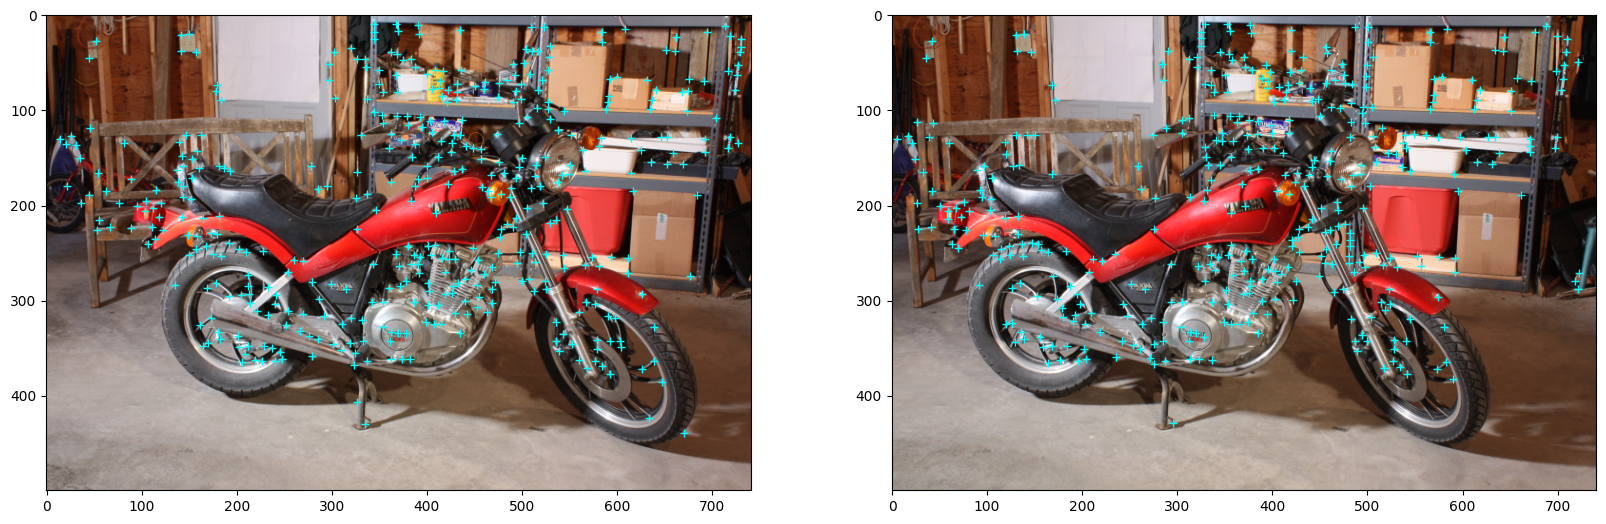

In [7]:
fig, axs = plt.subplots(1,2, figsize=(20,10))
for i,img in enumerate(imgs_motorcycle):
    coords = feature.corner_peaks(feature.corner_harris(color.rgb2gray(img)), min_distance=5, threshold_rel=0.02)
    axs[i].imshow(img, cmap=plt.cm.gray)
    axs[i].plot(coords[:, 1], coords[:, 0], color='cyan', marker='+', linestyle='None', markersize=6)
plt.show()

Generamos ahora una imagen binarizada artificial, con esquinas bien apreciables, y probamos en ella un refinamiento subpíxel (más preciso) de la detección de esquinas:

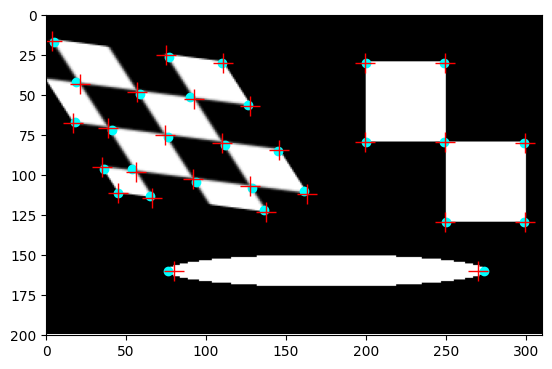

In [4]:
# Sheared checkerboard
tform = transform.AffineTransform(scale=(1.3, 1.1), rotation=1, shear=0.7,
                        translation=(110, 30))
image = transform.warp(img_checkerboard[:90, :90], tform.inverse,
             output_shape=(200, 310))
# Ellipse
rr, cc = draw.ellipse(160, 175, 10, 100)
image[rr, cc] = 1
# Two squares
image[30:80, 200:250] = 1
image[80:130, 250:300] = 1

coords = feature.corner_peaks(feature.corner_harris(image), min_distance=5, threshold_rel=0.02)
coords_subpix = feature.corner_subpix(image, coords, window_size=13)

fig, ax = plt.subplots()
ax.imshow(image, cmap=plt.cm.gray)
ax.plot(coords[:, 1], coords[:, 0], color='cyan', marker='o',
        linestyle='None', markersize=6)
ax.plot(coords_subpix[:, 1], coords_subpix[:, 0], '+r', markersize=15)
ax.axis((0, 310, 200, 0))
plt.show()

# Detección de _blobs_ (LoG, DoG, DoH)

Se ilustran tres posibles métodos para computar _blobs_ en una imagen:
* Laplaciana de la Gaussiana
* Diferencia de Gaussianas (aproximación del anterior)
* Determinante del Hessiano (cuya aproximación integral es usada por SURF)

Ilustramos los resultados con una imagen obtenida con el telescopio Hubble, donde se aprecia bien la sensibilidad a los _blobs_ (en este caso galaxias) a distintas escalas:

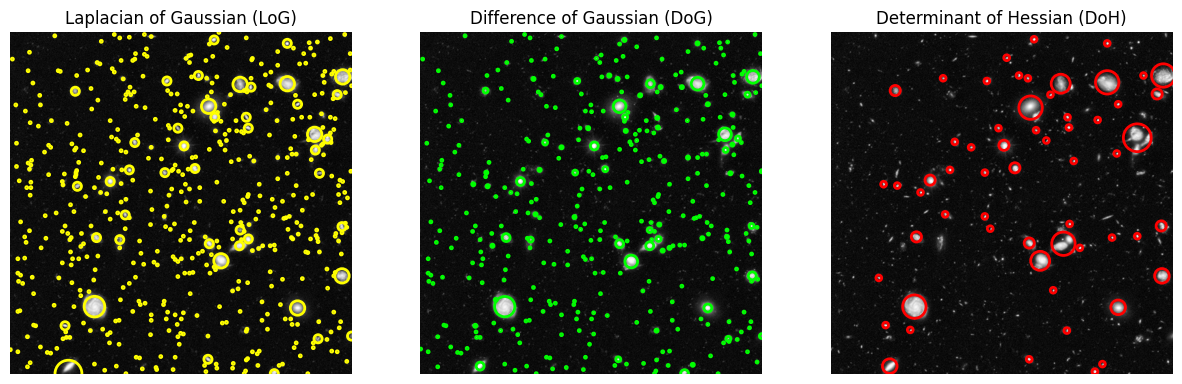

In [8]:
blobs_log = blob_log(img_hubble_gray, max_sigma=30, num_sigma=10, threshold=.1)
blobs_dog = blob_dog(img_hubble_gray, max_sigma=30, threshold=.1)
blobs_doh = blob_doh(img_hubble_gray, max_sigma=30, threshold=.01)

# Corregimos radios (= desv. típica gaussiana) con raiz de 2:
blobs_log[:, 2] = blobs_log[:, 2] * math.sqrt(2)
blobs_dog[:, 2] = blobs_dog[:, 2] * math.sqrt(2)

blobs_list = [blobs_log, blobs_dog, blobs_doh]
colors = ['yellow', 'lime', 'red']
titles = ['Laplacian of Gaussian (LoG)', 'Difference of Gaussian (DoG)',
          'Determinant of Hessian (DoH)']

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, (blobs, color, title) in enumerate(zip(blobs_list, colors, titles)):
    ax[i].set_title(title)
    ax[i].imshow(img_hubble_gray, cmap="gray")
    for blob in blobs:
        y, x, r = blob
        ax[i].add_patch(plt.Circle((x, y), r, color=color, linewidth=2, fill=False))
    ax[i].set_axis_off()

# Un primer descriptor de ejemplo: histograma de gradientes orientados (HOGs)

Es un método para caracterizar una ventana de imagen de tamaño dado. Aunque hoy en día se considera obsoleto, ilustra bien el uso de grids de gradiente local como descriptores para poder, por ejemplo, detectar personas en imágenes (estos histogramas de gradientes tienen una filosofía similar a los descriptores SIFT, que repasaremos también en el último apartado del notebook):

1. Se computa la imagen gradiente, con su correspondiente orientación y magnitud en cada píxel.
2. Se divide la imagen en bloques de 2x2 celdas de tamaño 32x32, con solapamiento de un 50%.
3. Se cuantiza la orientación del gradiente en 9 orientaciones en cada celda, y cada píxel vota (ponderados por distancia al centro del bloque con una gaussiana, y usando interpolación bilineal entre orientaciones discretizadas) en los _bins_ de orientación más cercanos en su celda.
4. Se concatenan todos los histogramas, para generar un vector de 8100 componentes.

(La imagen tiene 512 píxeles de altura y anchura, que corresponden a (512/32=16) 16x16 celdas, que al ser tratadas por bloques de 2x2 con solapamiento, producen 15x15 bloques, para los que se recaban 4 histogramas de 9 orientaciones cada uno $→ 15\times15\times4\times9=8100$)

Un vídeo con una explicación de los detalles se puede encontrar [aquí](https://www.youtube.com/watch?v=0Zib1YEE4LU).


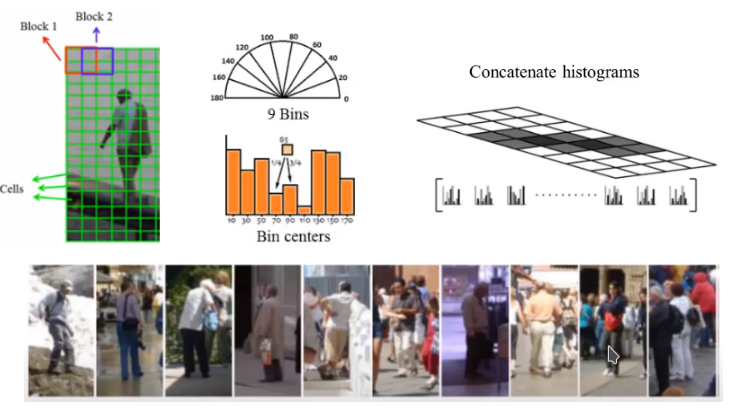

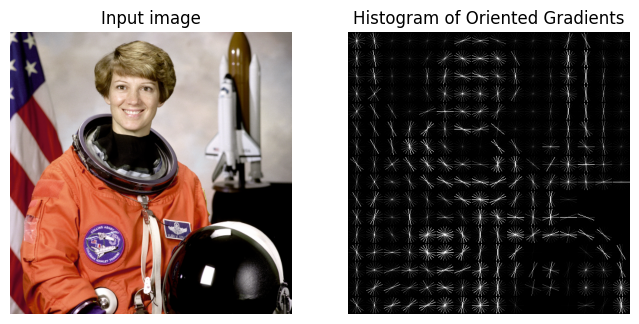

(dtype('float64'), (8100,), np.float64(0.0), np.float64(0.7218208419380614))

In [9]:
image = data.astronaut()

fd, hog_image = hog(image, orientations=9, pixels_per_cell=(32, 32), cells_per_block=(2, 2), visualize=True, channel_axis=2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()
fd.dtype, fd.shape, fd.min(), fd.max()

In [10]:
print(image.shape[:2]) # Tamaño de imagen de entrada
print(15*15*9*4)       # Tamaño del vector HoG generado

(512, 512)
8100


# Detector + descriptor SIFT

Una vez repasados algunos extractores básicos de contornos, esquinas y blobs en imágenes, pasamos por último a las _hand engineered features_ más potentes de la visión artificial clásica (no basada en Deep Learning). Los principales objetivos de lo que resta de este notebook se resumen en lo siguiente:

* Ilustrar la metodología general de trabajo para obtener y utilizar *features* invariantes a escala, rotación y luminosidad (SIFT), en el contexto de una aplicación de reconocimiento de objetos planares con suficiente textura.
* Trabajar en un problema real de tratamiento de *outliers* mediante RANSAC, en el contexto del *matching* entre una base de datos de imágenes de objetos a reconocer y una nueva imagen de entrada.
* Resolver el problema de la estimación de la transformación (euclídea, afín o perspectiva) que ubica de forma precisa en la imagen de entrada el modelo correspondiente al objeto de la base de datos detectado.


## Extracción de características SIFT de una imagen

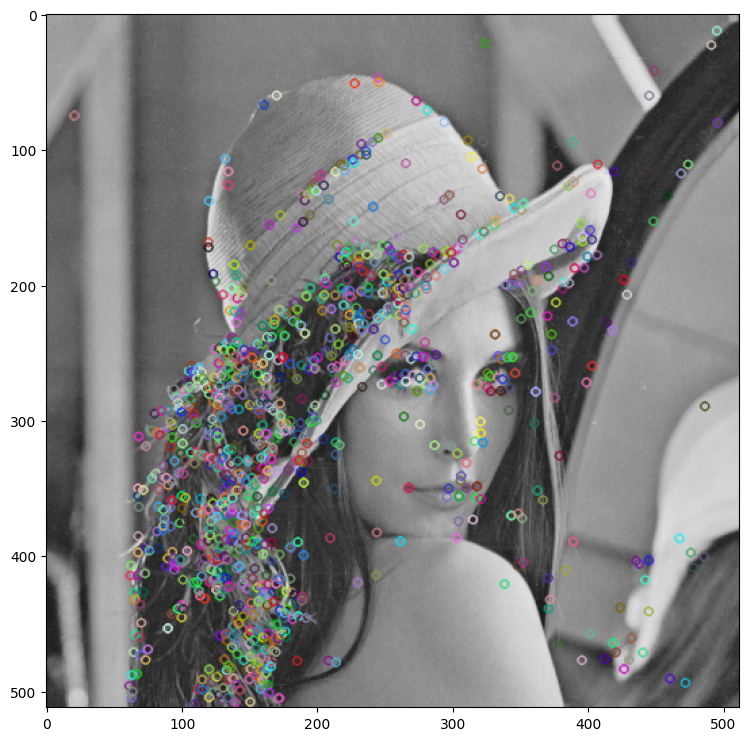

In [11]:
img = cv2.imread('Lenna.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Creamos detector SIFT...
sift = cv2.xfeatures2d.SIFT_create()
# ... Y lo llamamos sobre una imagen de grises:
kps, descrs = sift.detectAndCompute(gray,None)

# Dibujamos las posiciones de los SIFT extraídos sobre la imagen original:
imgout = cv2.drawKeypoints(gray, kps, cv2.DrawMatchesFlags_DEFAULT)
fig, ax = plt.subplots(1,1,figsize=(9,9))
ax.imshow(imgout);

En la imagen anterior no se aprecian ni los tamaños de los *blobs* ni las orientaciones dominantes (*orientación canónica*) de los mismos.

Podemos utilizar los campos de los *keypoints* extraidos para acceder a dicha información:

In [12]:
[attr for attr in dir(kps[0]) if not attr.startswith("__")]

['angle', 'class_id', 'convert', 'octave', 'overlap', 'pt', 'response', 'size']

En particular, usaremos los campos *size* y *angle*. El código de la siguiente celda usa matplotlib para mostrar gráficamente la información de tamaño y orientación de cada *blob*:

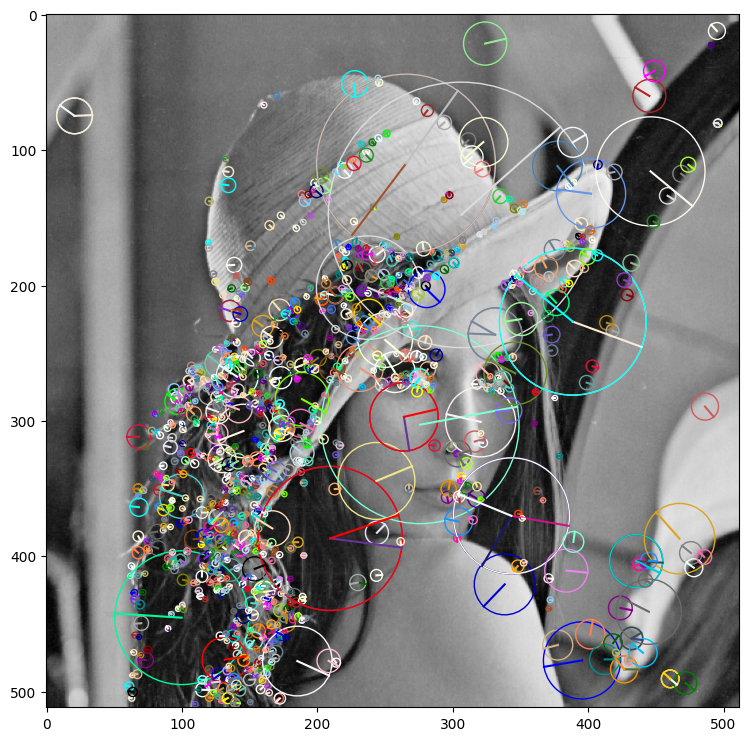

In [13]:
fig, ax = plt.subplots(1,1,figsize=(9,9))
ax.imshow(gray, cmap='gray');
colors = list(mcolors.CSS4_COLORS.keys()) # Lista de colores diferentes.
for i, kp in enumerate(kps):
  circle = plt.Circle(kp.pt, kp.size, fill=False, color=colors[i%len(colors)])
  ax.add_patch(circle)
  l = mlines.Line2D([kp.pt[0],kp.pt[0]+math.cos(math.radians(kp.angle))*kp.size],
                    [kp.pt[1],kp.pt[1]+math.sin(math.radians(kp.angle))*kp.size], color=colors[i%len(colors)])
  ax.add_line(l)

## Descriptores SIFT

Cada keypoint, además de su localización, tamaño, y orientación característica, viene asociado con un vector característico, de dimensión 128, y cuyos valores (como se vio en la clase de teoría) están relacionados con los histogramas de gradientes locales en el entorno del blob correspondiente.

Veamos, por ejemplo, el descriptor asociado a uno de los *blobs* extraídos:

In [14]:
descrs[0]

array([  0.,   1.,   0.,   1.,  58., 153.,   0.,   0.,  29.,   0.,   0.,
         1.,  15.,  69.,   2.,  24.,  42.,   0.,   0.,   0.,   0.,   0.,
         0.,  36.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  10.,
        34.,   0.,   0.,  42., 153.,   0.,   0.,  90.,   2.,   0.,   0.,
        54., 153.,   9.,  19., 153.,  17.,   0.,   0.,   1.,  13.,   5.,
        47.,  16.,   3.,   0.,   0.,   0.,   0.,   0.,   2.,  53., 153.,
         0.,   0.,   9.,  48.,   0.,   0.,  24.,  16.,   0.,   0.,  44.,
       153.,  27.,  16., 153.,  13.,   0.,   0.,   3.,  54.,  34.,  68.,
        31.,   5.,   1.,   4.,   4.,   0.,   0.,   3.,  74., 153.,   0.,
         0.,   1.,   3.,   1.,   0.,  24., 114.,   2.,   0.,   9.,  47.,
        11.,   3.,  23.,   3.,   0.,   1.,   4.,  23.,  26.,  49.,   6.,
         0.,   0.,  10.,  14.,   0.,   0.,   6.], dtype=float32)

Vemos que se trata de un vector de 128 componentes, con valores entre 0 y 255. El siguiente código dibuja, p.e., el descriptor asociado al *blob* más grande de entre los extraídos:

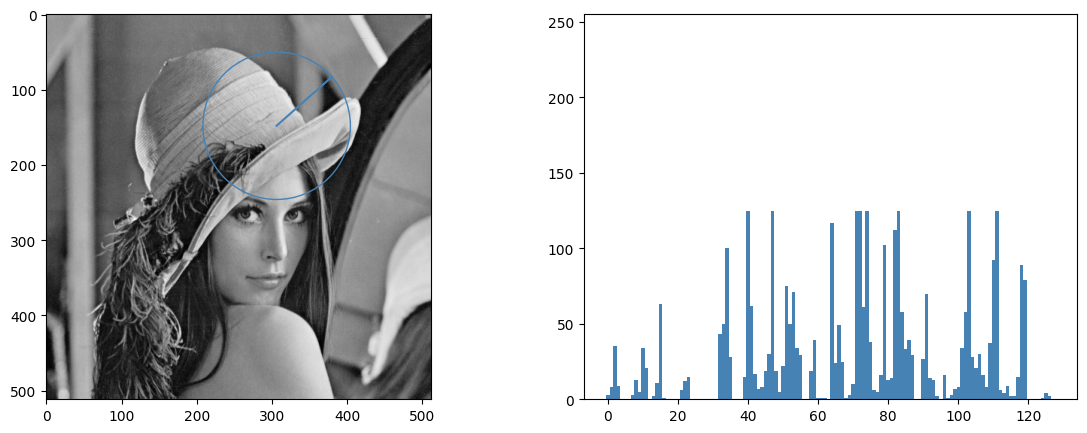

In [15]:
# Formamos una lista de pares (keypoint,descriptor):
listkpsdesrcs = list(zip(kps,descrs))
# La ordenamos por tamaño (campo .size del keypoint):
listkpsdesrcs.sort(key=lambda x: x[0].size)
# Nos quedamos con el último keypoint (el más grande):
(kp,desc) = listkpsdesrcs[-1]

# Dibujamos tanto el blob como, a su lado, los valores del vector 128-dimensional
# del descriptor asociado:
fig, axs = plt.subplots(1,2,figsize=(14,5))
axs[0].imshow(gray, cmap='gray');
circle = plt.Circle(kp.pt, kp.size, fill=False, color='steelblue')
axs[0].add_patch(circle)
l = mlines.Line2D([kp.pt[0],kp.pt[0]+math.cos(math.radians(kp.angle))*kp.size],
                [kp.pt[1],kp.pt[1]+math.sin(math.radians(kp.angle))*kp.size],
                color='steelblue')
axs[0].add_line(l)
axs[1].bar(np.arange(128), desc, align='center', width=1, color='steelblue')
axs[1].set_ylim([0, 255]);

## *Matching* entre imágenes usando SIFT

El siguiente código muestra cómo se puede hacer el reconocimiento de un objeto, de forma aproximadamente planar, en una escena general.

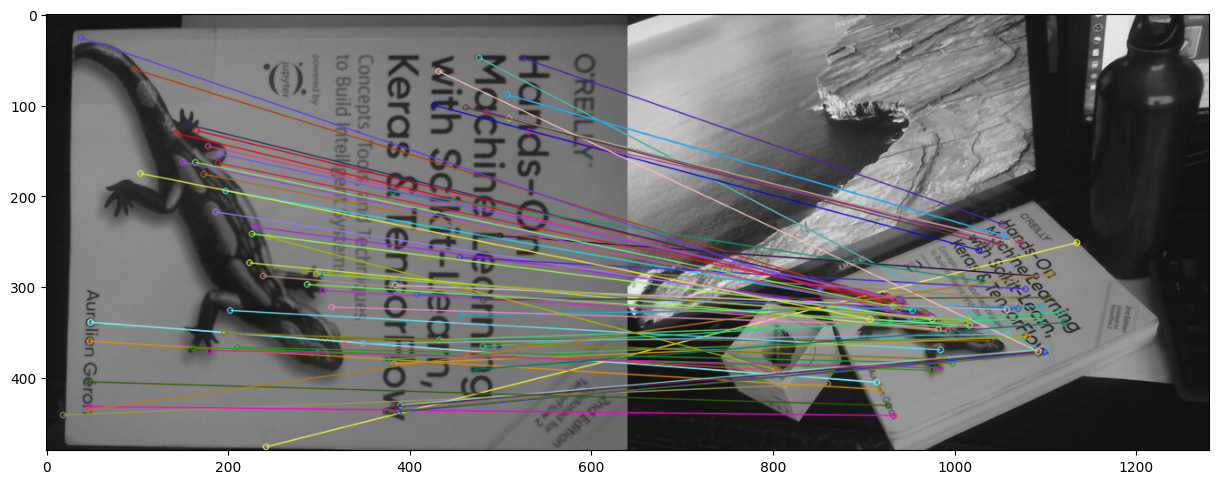

In [16]:

# Leemos la imagen del modelo, y de la escena:
img1 = cv2.imread('HOML-model.jpg')
img2 = cv2.imread('HOML-scene.jpg')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Creamos el dectector de SIFT, y extraemos los keypoints y descriptores
# asociados en sendas imágenes:
sift = cv2.xfeatures2d.SIFT_create()
keypoints_1, descriptors_1 = sift.detectAndCompute(img1,None)
keypoints_2, descriptors_2 = sift.detectAndCompute(img2,None)

# Creamos un matcher para hacer el matching (en este caso, un matcher por
# "fuerza bruta"):
bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck=True)

# Calculamos los matches, y ordenamos los emparejamientos obtenidos según distancia:
matches = bf.match(descriptors_1,descriptors_2)
matches = sorted(matches, key = lambda x:x.distance)

# Dibujamos los matchings (sólo los 75 primeros, para no entorpecer
# demasiado la claridad del dibujo):
img3 = cv2.drawMatches(img1, keypoints_1, img2, keypoints_2, matches[:75], img2, flags=2)
fig, ax = plt.subplots(1,1,figsize=(15,7))
ax.imshow(img3);

Los campos `queryIdx` y `trainIdx` de cada _match_ contienen los índices a los keypoints originales. Por ejemplo:

In [17]:
print(matches[1].distance,matches[1].queryIdx,matches[1].trainIdx)
print(keypoints_1[188].pt, keypoints_2[1199].pt)

478.0 188 1199
(241.6765899658203, 476.0088806152344) (494.1387634277344, 251.11380004882812)


# Detección de objetos con RANSAC y estimación de homografía (ejercicio)

En el _matching_ anterior, sin embargo, se puede observar que hay bastantes matching correctos, pero también unos cuantos incorrectos.

Es, por tanto, necesario aplicar una técnica de estimación robusta para poder estimar correctamente la homografía de transformación entre el modelo y la imagen.

Se trata, pues de un ejemplo típico de utilización de RANSAC en un contexto más general que la simple estimación de rectas. En el apartado final de referencias tenéis unos cuantos enlaces (particularmente útiles os resultarán los dos últimos) a partir de los cuales sería inmediato terminar la detección del objeto libro anterior en la imagen de la derecha. **Se deja, pues, terminar dicha detección precisa (ubicar el rectángulo proyectado en la imagen derecha con la detección precisa del libro) como ejercicio**.


## Referencias

* Método `cv2.findHomography` de la OpenCV: [aquí](https://docs.opencv.org/master/d9/d0c/group__calib3d.html#ga4abc2ece9fab9398f2e560d53c8c9780).

* Método `cv2.estimateAffine2D` de la OpenCV: [aquí](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html#ga27865b1d26bac9ce91efaee83e94d4dd).

* Método `cv2.estimateAffinePartial2D` de la OpenCV: [aquí](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html#gad767faff73e9cbd8b9d92b955b50062d)

* Tutorial de introducción al uso de SIFT con la OpenCV: [aquí](https://docs.opencv.org/master/da/df5/tutorial_py_sift_intro.html).

* Tutorial de *matching* de *features* con la OpenCV: [aquí](https://docs.opencv.org/master/dc/dc3/tutorial_py_matcher.html).

* Tutorial de detección de objetos con la OpenCV: [aquí](https://docs.opencv.org/master/d1/de0/tutorial_py_feature_homography.html).
